# Sign language recognition

Sign language recognition plays a crucial role in bridging the communication gap between hearing and deaf communities.
In this notebook, we build upon the existing VGG19-based sign language classification model to enhance its robustness and interpretability. Specifically, we introduce several improvements:
Segmentation-based representation using hand masks generated by a U-Net model, 
Explainable AI (XAI) methods, including Grad-CAM, LIME, and Integrated Gradients, to better interpret model decisions and ensure transparency.
We conduct a comparative analysis between RGB-based and mask-based models. While the RGB model leverages rich color and texture information, the mask-based model focuses more effectively on hand shape and structure.
Through the integration of XAI, we validate the model’s behavior by visualizing the key image regions that influence predictions. This multi-perspective interpretability approach — combining region-based attention, pixel-level attribution, and structural analysis — provides a deeper understanding of the model’s internal representations and potential failure cases.

Overall, this work contributes to advancing American Sign Language recognition by improving both generalization and explainability, thereby promoting greater trust and usability in real-world assistive technologies.

# Import the Libraries

In [5]:
!pip install tf-explain


In [6]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import glob
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tf_explain.core.grad_cam import GradCAM
from keras.models import load_model
from lime import lime_image
from skimage.segmentation import mark_boundaries
import pickle
import scipy.stats as st

## Load Label Encoder and Models
Load the label binarizer (for mapping output indices to letters) and the two Keras models: the mask (segmentation) model and the color/classification model.


In [7]:
# --- Load label encoder (pickle) ---
# Loading the label binarizer that maps model outputs to readable class labels.

with open("/kaggle/input/pkl-ltter/other/default/1/lbl_binarizer.pkl", 'rb') as file:
    lbl_binarizer = pickle.load(file)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator LabelBinarizer from version 0.24.2 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
# --- Load trained Keras models ---
# Load the pre-trained mask (segmentation) model and the color/classification model.
model_colour= load_model("/kaggle/input/model/keras/default/1/my_model_colour.h5")
model_mask=load_model("/kaggle/input/model/keras/default/1/my_model_mask.h5")
model_seg = load_model("/kaggle/input/model/keras/default/1/unet (4).h5")

I0000 00:00:1761763613.321272      93 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


## Images


In [9]:
path_a="/kaggle/input/letter/a.jpg"
path_l="/kaggle/input/letter/l.jpg"
path_i="/kaggle/input/letter/i.jpg"
path_j="/kaggle/input/letter/j.png"
path_m="/kaggle/input/letter/m.jpg"
path_n="/kaggle/input/letter/n.jpg"

## Image Preprocessing and Segmentation
Functions to segment the hand region from the image using the mask model and basic CV operations. Produces a normalized mask and preprocessed image arrays for the classifier.


In [10]:

# lettre a
image_a= load_img(path_a, target_size=(64, 64))
image_array_a = img_to_array(image_a) / 255.0
image_input_a= np.expand_dims(image_array_a, axis=0)

# lettre l
image_l= load_img(path_l, target_size=(64, 64))
image_array_l= img_to_array(image_l) / 255.0
image_input_l= np.expand_dims(image_array_l, axis=0)

# lettre i
image_i= load_img(path_i, target_size=(64, 64))
image_array_i = img_to_array(image_i) / 255.0
image_input_i= np.expand_dims(image_array_i, axis=0)


# lettre j
image_j= load_img(path_j, target_size=(64, 64))
image_array_j = img_to_array(image_j) / 255.0
image_input_j= np.expand_dims(image_array_j, axis=0)

# lettre m
image_m= load_img(path_m, target_size=(64, 64))
image_array_m = img_to_array(image_m) / 255.0
image_input_m= np.expand_dims(image_array_m, axis=0)


# lettre n
image_n= load_img(path_n, target_size=(64, 64))
image_array_n = img_to_array(image_n) / 255.0
image_input_n= np.expand_dims(image_array_n, axis=0)

## Run Segmentation and Save Masks
Run the segmentation function on example images and save resulting masks to disk (for demonstration).


In [11]:
# --- Segmentation function ---
# `seg_img` takes an image path, runs the mask model to obtain a segmentation mask,
# applies morphological operations if needed, and returns a normalized mask/image ready for classification.

def seg_img(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    image = cv2.resize(image, (128, 128))
    img = image.astype('float32') / 255
    img= np.expand_dims(img, axis=0)
    i=(-1 * model_seg.predict(img) + 1) > 0.4
    i=i.reshape((128, 128))
    plt.imshow(i)
    plt.axis('off')
    plt.show()
    # Enregistrer l'image redimensionnée
    cv2.imwrite("image_resized.jpg", i*255)
    return i

I0000 00:00:1761763618.987740     161 service.cc:148] XLA service 0x78a89400b690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761763618.988369     161 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1761763619.162236     161 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


I0000 00:00:1761763620.583983     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


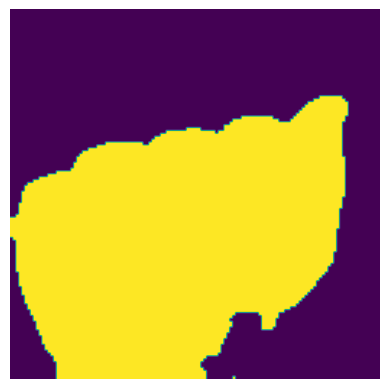

[ WARN:0@468.062] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


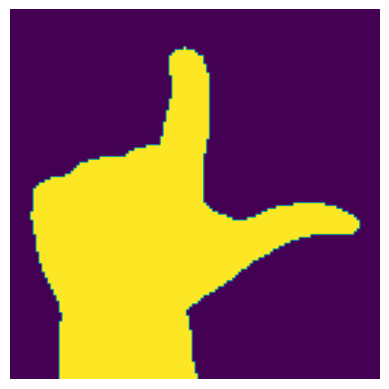

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


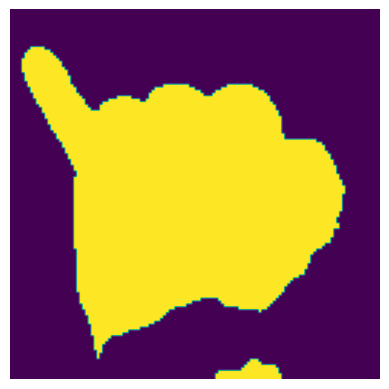

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


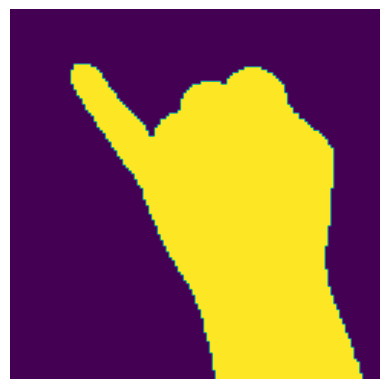

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


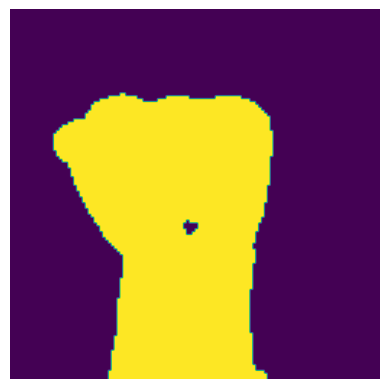

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


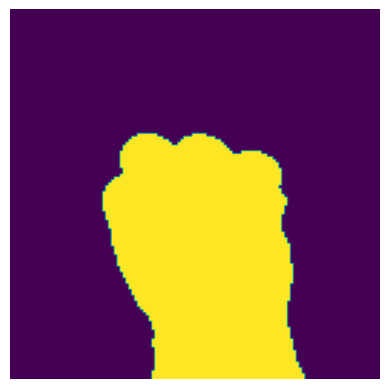

True

In [12]:
i=seg_img(path_a)
cv2.imwrite("mask_a.jpg",i*255.0)
i=seg_img(path_l)
cv2.imwrite("mask_l.jpg",i*255.0)
i=seg_img(path_i)
cv2.imwrite("mask_i.jpg",i*255.0)
i=seg_img(path_j)
cv2.imwrite("mask_j.jpg",i*255.0)
i=seg_img(path_m)
cv2.imwrite("mask_m.jpg",i*255.0)
i=seg_img(path_n)
cv2.imwrite("mask_n.jpg",i*255.0)

## Model Interpretability: Understanding Predictions

In this section, we explore model interpretability techniques to better understand the decision-making process of our deep learning model for sign language image classification.
Understanding where and how the model focuses on the input image is crucial for:
Validating model behavior: Ensure that predictions are based on meaningful regions (e.g., the hand shape) rather than irrelevant background.
Debugging and improving models: Identify if the model is relying on spurious features or artifacts.
Communicating results: Provide explainable insights to end-users or stakeholders.
We will use three complementary methods:
Grad-CAM – Visualizes class-specific regions in the feature maps of convolutional layers.
LIME (Local Interpretable Model-Agnostic Explanations) – Provides local, superpixel-based interpretability for individual predictions.
Integrated Gradients – Computes pixel-level attribution to quantify the contribution of each pixel to the predicted class.

This combination allows us to perform both qualitative and quantitative analyses of the model’s attention.
Quantitative Analysis:
Two metrics are computed from the LIME saliency map:
Energy Concentration: Measures how much of the model’s attention is captured by the top 5%, 10%, and 20% most activated regions.
A more focused explanation leads to higher energy concentration values.
Entropy: Evaluates the spread or uncertainty of the saliency distribution.
Lower entropy indicates that the model bases its decision on compact, discriminative regions.

## Grad-CAM



In [14]:
def gradcam(image, model):
    """
    Compute Grad-CAM heatmap for an input PIL-like image and a Keras model,
    display the superimposed result, and return the superimposed image.

    Assumes the following are available in the environment:
    - img_to_array, np, GradCAM, st (scipy.stats), cv2, plt
    """
    # Convert image to array and normalize to [0, 1]
    image_array = img_to_array(image) / 255.0
    # Add batch dimension for model input
    image_input = np.expand_dims(image_array, axis=0)

    # Initialize Grad-CAM explainer
    explainer = GradCAM()
    # Run model prediction on the input
    predictions = model.predict(image_input)
    # Get the predicted class index
    predicted_class = np.argmax(predictions[0])
    print(predicted_class)

    # Apply Grad-CAM to obtain the heatmap for the predicted class
    heatmap = explainer.explain(
        validation_data=(image_input, None),
        model=model,
        layer_name="block5_conv4",
        class_index=predicted_class
    )

    # Normalize heatmap to range 0–1
    heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    flat = heatmap_norm.flatten()
    sorted_vals = np.sort(flat)[::-1]
    total = flat.sum() + 1e-8

    # Fractions to test for energy concentration
    fractions = [0.05, 0.10, 0.20]  # 5%, 10%, 20%
    for f in fractions:
        k = int(f * len(sorted_vals))
        energy_top = sorted_vals[:k].sum() / total
        print(f"Energy concentration (top {int(f*100)}%) = {energy_top*100:.1f}%")

    # Compute entropy of the heatmap distribution
    entropy = st.entropy(flat + 1e-8)
    print(f"Entropy of heatmap = {entropy:.3f}")

    # Resize heatmap to match input image size and apply a color map
    heatmap = cv2.resize(heatmap, (image.width, image.height))
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

    # Superimpose the heatmap onto the original image
    superimposed_img = cv2.addWeighted(
        cv2.cvtColor(image_array, cv2.COLOR_RGB2BGR), 0.6,
        heatmap, 0.4, 0, dtype=cv2.CV_8U
    )

    # Display the original image with the heatmap overlay
    fig, ax = plt.subplots()
    ax.imshow(superimposed_img)
    ax.axis('off')
    plt.show()

    return superimposed_img


## LIME: Local Interpretable Model-Agnostic Explanations


In [15]:
def explain_with_lime(model, image_array, save_path,
                      positive_only=True, num_features=5, num_samples=1000,
                      top_frac_list=(0.05, 0.10, 0.20)):
    """
    Generate a LIME-based saliency explanation for a given image and model.
    Computes both qualitative (visual) and quantitative (energy and entropy) analyses.
    """

    # -- Prepare the image for LIME (convert to uint8, range 0–255)
    if image_array.dtype != np.uint8:
        img_uint8 = (np.clip(image_array * 255.0, 0, 255)).astype(np.uint8) if image_array.max() <= 1.0 else image_array.astype(np.uint8)
    else:
        img_uint8 = image_array

    H, W = img_uint8.shape[:2]
    explainer = lime_image.LimeImageExplainer(random_state=42)

    # Define prediction function for LIME (normalizing inputs if needed)
    def predict_fn(xs):
        xs = np.asarray(xs, dtype=np.float32)
        if xs.max() > 1.0:
            xs = xs / 255.0
        return model.predict(xs)

    # Run LIME explanation
    exp = explainer.explain_instance(
        img_uint8, predict_fn, top_labels=1, hide_color=0, num_samples=num_samples
    )

    # Retrieve top predicted class and corresponding superpixel segmentation
    class_id = exp.top_labels[0]
    segments = exp.segments
    weights = dict(exp.local_exp[class_id])  # {superpixel_idx: weight}

    # ---- Construct a continuous saliency map ----
    sal = np.zeros((H, W), dtype=np.float32)
    has_pos = False
    for sp, w in weights.items():
        if positive_only and w <= 0:
            continue
        has_pos = has_pos or (w > 0)
        sal[segments == sp] = max(sal[segments == sp].max(), abs(float(w)))

    # Fallback: if no positive regions found, use absolute weights
    if sal.max() == 0:
        for sp, w in weights.items():
            sal[segments == sp] = abs(float(w))

    # Normalize and compute quantitative metrics
    smin, smax = float(sal.min()), float(sal.max())
    print(f"[LIME] saliency min={smin:.6f} max={smax:.6f}")
    if smax <= smin + 1e-12:
        energy = {f: 0.0 for f in top_frac_list}
        entropy = 0.0
    else:
        sal01 = (sal - smin) / (smax - smin)
        flat = sal01.flatten().astype(float)
        total = float(flat.sum()) + 1e-8
        order = np.sort(flat)[::-1]

        # Compute energy concentration in top fractions
        energy = {}
        for f in top_frac_list:
            k = max(1, int(round(f * order.size)))
            energy[f] = float(order[:k].sum() / total)

        # Compute entropy of saliency distribution
        entropy = float(st.entropy(flat + 1e-8))

    # ---- Print metrics ----
    for f in top_frac_list:
        print(f"[LIME] Energy (top {int(f*100)}%) = {energy[f]*100:.1f}%")
    print(f"[LIME] Entropy = {entropy:.3f}")

    # ---- Visualization and saving the explanation ----
    temp, mask = exp.get_image_and_mask(class_id, positive_only=True, num_features=1, hide_rest=False)
    fig, ax = plt.subplots()
    ax.imshow(mark_boundaries(temp, mask))
    plt.axis('off')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved explanation image at: {save_path}")

    # ---> Return computed metrics
    return (energy, entropy)


## Integrated Gradients (IG) 

In [17]:
def integrated_gradients(model, image, name, target_class_index, steps=50):
    """
    Compute Integrated Gradients (IG) for a given image and model.
    Displays the heatmap, saves it to a file, and computes quantitative metrics (energy and entropy).

    Parameters:
    - model: Keras/TensorFlow model
    - image: input image (numpy array)
    - name: filename to save the heatmap
    - target_class_index: index of the class for which to compute IG
    - steps: number of interpolation steps between baseline and image
    """

    # --- Baseline (reference) image: all zeros ---
    baseline = np.zeros_like(image)
    # Convert the input image to a TensorFlow tensor
    image_input = tf.convert_to_tensor(image, dtype=tf.float32)

    # --- Interpolate between baseline and input image ---
    interpolated_images = [(baseline + (step / steps) * (image - baseline)) for step in range(steps)]
    interpolated_images = np.array(interpolated_images)
    interpolated_images = tf.convert_to_tensor(interpolated_images, dtype=tf.float32)

    # Remove extra dimension if present
    interpolated_images = tf.squeeze(interpolated_images, axis=1)

    # --- Compute gradients ---
    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        predictions = model(interpolated_images)
        target_class_probabilities = predictions[:, target_class_index]

    grads = tape.gradient(target_class_probabilities, interpolated_images)

    # --- Integrated gradients: average gradients * (image - baseline) ---
    integrated_grads = np.mean(grads, axis=0) * (image - baseline)

    # --- Compute heatmap by summing across channels ---
    heatmap = np.sum(integrated_grads, axis=-1)
    integrated_gradients_heatmap = np.squeeze(heatmap)

    # --- Display and save heatmap ---
    plt.imshow(integrated_gradients_heatmap, cmap='hot')
    plt.colorbar()
    plt.savefig(name, bbox_inches='tight', dpi=300)
    plt.show()

    # --- Normalize heatmap to 0–1 ---
    hmin, hmax = float(heatmap.min()), float(heatmap.max())
    if hmax > hmin:
        heatmap_norm = (heatmap - hmin) / (hmax - hmin)
    else:
        heatmap_norm = np.zeros_like(heatmap, dtype=np.float32)

    # --- Compute quantitative metrics ---
    flat = heatmap_norm.flatten().astype(float)
    total = flat.sum() + 1e-8
    order = np.sort(flat)[::-1]

    energy = {}
    for f in (0.05, 0.10, 0.20):  # top 5%, 10%, 20%
        k = max(1, int(round(f * order.size)))
        energy[f] = float(order[:k].sum() / total)

    entropy = float(st.entropy(flat + 1e-8))

    # --- Print metrics ---
    print("[IG] Energy concentration:")
    print(f"  top-5%  = {energy[0.05]*100:.1f}%")
    print(f"  top-10% = {energy[0.10]*100:.1f}%")
    print(f"  top-20% = {energy[0.20]*100:.1f}%")
    print(f"[IG] Entropy = {entropy:.3f}")

    # Return heatmap metrics if needed
    return integrated_gradients_heatmap, energy, entropy


## Application

## Letter a

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
0
Energy concentration (top 5%) = 6.5%
Energy concentration (top 10%) = 13.0%
Energy concentration (top 20%) = 26.1%
Entropy of heatmap = 9.384


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


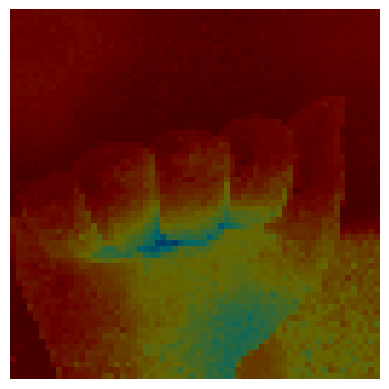

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
0


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_3']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


Energy concentration (top 5%) = 7.5%
Energy concentration (top 10%) = 15.1%
Energy concentration (top 20%) = 30.1%
Entropy of heatmap = 9.254


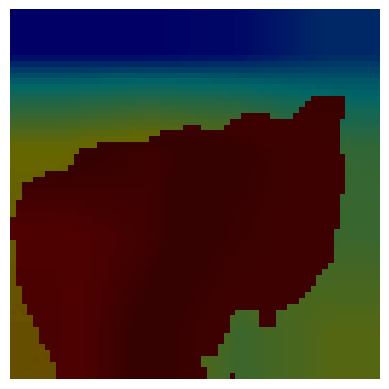

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

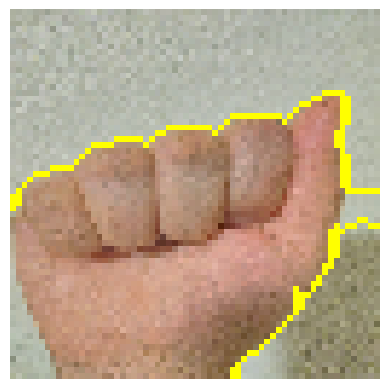

Saved explanation image at: lime_a.jpg
Returned LIME: {0.05: 0.0919176226763821, 0.1: 0.1838352453527642, 0.2: 0.3672221120583265} 7.742025608384221


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━

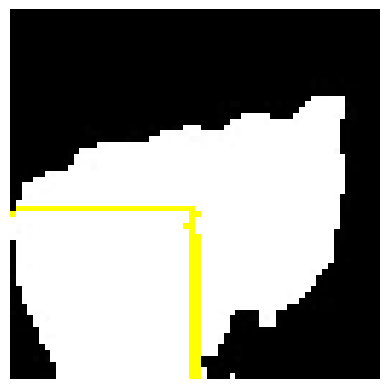

Saved explanation image at: lime_mask_a.jpg
Returned LIME: {0.05: 0.1106290871508124, 0.1: 0.2212581743016248, 0.2: 0.44197669451958715} 7.834839609000584


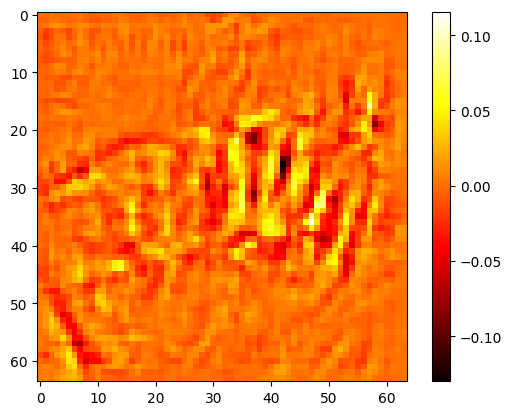

[IG] Energy concentration:
  top-5%  = 6.7%
  top-10% = 12.5%
  top-20% = 23.5%
[IG] Entropy = 8.308


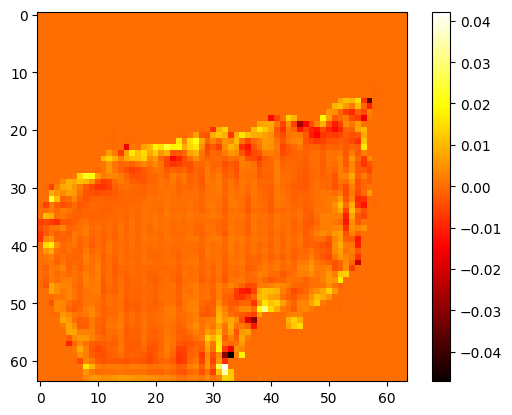

[IG] Energy concentration:
  top-5%  = 6.1%
  top-10% = 11.4%
  top-20% = 21.6%
[IG] Entropy = 8.315


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 {0.05: 0.06069485148224818,
  0.1: 0.11391978695205485,
  0.2: 0.21565215524746903},
 8.315092353354007)

In [18]:
image_mask= load_img('mask_a.jpg', target_size=(64, 64))

# Apply Grad-CAM for letter 'a' in RGB
img_grad = gradcam(image_a, model_colour)
img_grad = cv2.resize(img_grad, (500, 500))
cv2.imwrite("image_grad_a.jpg", cv2.cvtColor(img_grad, cv2.COLOR_BGR2RGB))

# Apply Grad-CAM for letter 'a' mask
ima_grad_mask = gradcam(image_mask, model_mask)
ima_grad_mask = cv2.resize(ima_grad_mask, (500, 500))
cv2.imwrite("image_grad_mask_a.jpg", cv2.cvtColor(ima_grad_mask, cv2.COLOR_BGR2RGB))

# LIME explanation
energy_lime, entropy_lime = explain_with_lime(model_colour, image_array_a, 'lime_a.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

image_array = img_to_array(image_mask)/255.0

energy_lime, entropy_lime = explain_with_lime(model_mask, image_array, 'lime_mask_a.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

# Display the heatmap to visualize gradients
integrated_gradients(model_colour, image_input_a, "gradient_a.jpg", target_class_index=0)
image_input = np.expand_dims(image_array, axis=0)
integrated_gradients(model_mask, image_input, "gradient_a_mask.jpg", target_class_index=0)


## Letter l

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
11
Energy concentration (top 5%) = 7.0%
Energy concentration (top 10%) = 14.0%
Energy concentration (top 20%) = 28.1%
Entropy of heatmap = 9.352


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


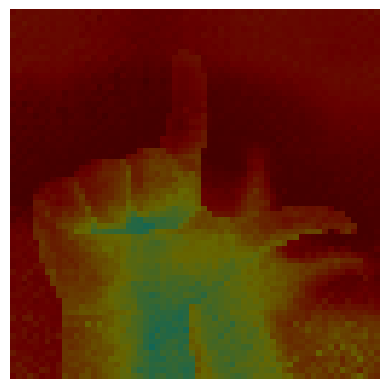

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
11


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_3']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


Energy concentration (top 5%) = 8.3%
Energy concentration (top 10%) = 16.6%
Energy concentration (top 20%) = 33.0%
Entropy of heatmap = 9.252


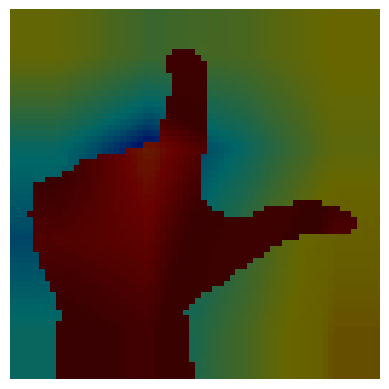

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━

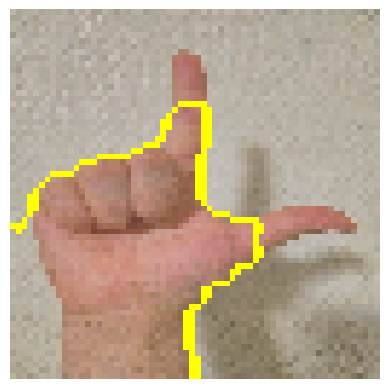

Saved explanation image at: lime_l.jpg
Returned LIME: {0.05: 0.07093960120816667, 0.1: 0.14187920241633334, 0.2: 0.2834123579975049} 8.075649220492231


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━

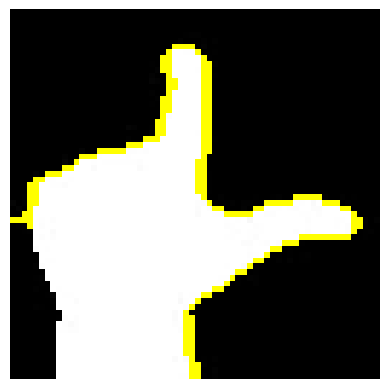

Saved explanation image at: lime_mask_l.jpg
Returned LIME: {0.05: 0.13451443569465543, 0.1: 0.26902887138931086, 0.2: 0.5374015747996234} 7.32909406400243


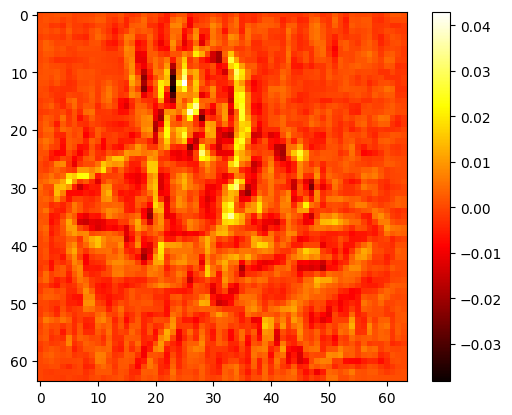

[IG] Energy concentration:
  top-5%  = 7.2%
  top-10% = 13.2%
  top-20% = 24.5%
[IG] Entropy = 8.304


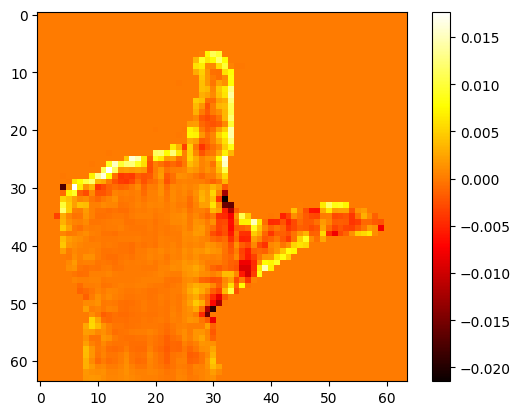

[IG] Energy concentration:
  top-5%  = 6.5%
  top-10% = 11.8%
  top-20% = 21.8%
[IG] Entropy = 8.313


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 {0.05: 0.06489269714056395,
  0.1: 0.11789547457547475,
  0.2: 0.21819967965516904},
 8.313331659015608)

In [20]:
image_mask = load_img('mask_l.jpg', target_size=(64, 64))

# Apply Grad-CAM for letter 'l' in RGB
img_grad = gradcam(image_l, model_colour)
img_grad = cv2.resize(img_grad, (500, 500))
cv2.imwrite("image_grad_l.jpg", cv2.cvtColor(img_grad, cv2.COLOR_BGR2RGB))

# Apply Grad-CAM for letter 'l' mask
ima_grad_mask = gradcam(image_mask, model_mask)
ima_grad_mask = cv2.resize(ima_grad_mask, (500, 500))
cv2.imwrite("image_grad_mask_l.jpg", cv2.cvtColor(ima_grad_mask, cv2.COLOR_BGR2RGB))

# LIME explanation
energy_lime, entropy_lime = explain_with_lime(model_colour, image_array_l, 'lime_l.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

image_array = img_to_array(image_mask)/255.0
energy_lime, entropy_lime = explain_with_lime(model_mask, image_array, 'lime_mask_l.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

# Display the heatmap to visualize gradients
integrated_gradients(model_colour, image_input_l, "gradient_l.jpg", target_class_index=11)

image_input = np.expand_dims(image_array, axis=0)
integrated_gradients(model_mask, image_input, "gradient_l_mask.jpg", target_class_index=11)


## Letter i

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
8
Energy concentration (top 5%) = 7.4%
Energy concentration (top 10%) = 14.7%
Energy concentration (top 20%) = 29.3%
Entropy of heatmap = 9.360


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


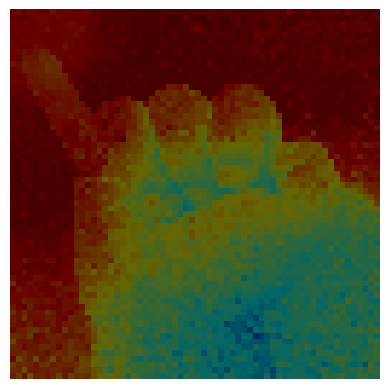

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
18


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_3']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


Energy concentration (top 5%) = 8.0%
Energy concentration (top 10%) = 16.0%
Energy concentration (top 20%) = 31.9%
Entropy of heatmap = 9.260


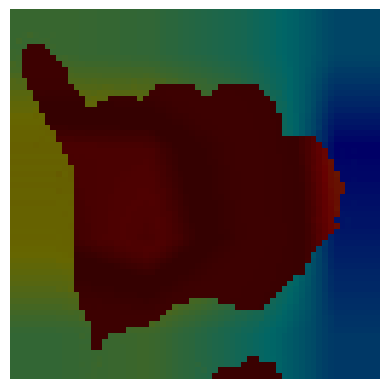

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

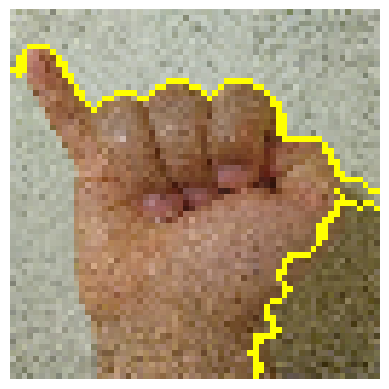

Saved explanation image at: lime_i.jpg
Returned LIME: {0.05: 0.07390840807124471, 0.1: 0.14781681614248943, 0.2: 0.29527310346511915} 7.997831497707687


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━

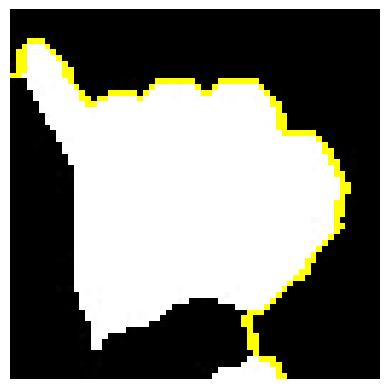

Saved explanation image at: lime_mask_i.jpg
Returned LIME: {0.05: 0.08080409932959873, 0.1: 0.16160819865919746, 0.2: 0.32282223098020174} 7.838737678940397


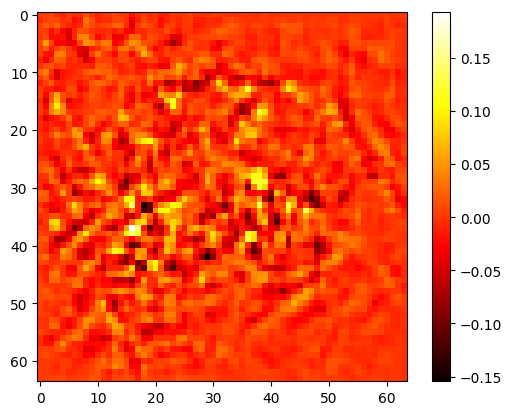

[IG] Energy concentration:
  top-5%  = 7.3%
  top-10% = 13.5%
  top-20% = 25.0%
[IG] Entropy = 8.300


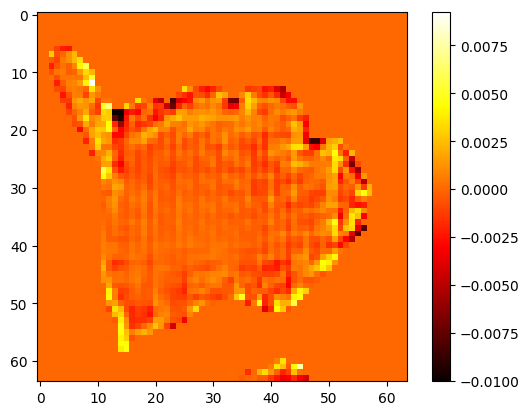

[IG] Energy concentration:
  top-5%  = 6.4%
  top-10% = 11.8%
  top-20% = 22.0%
[IG] Entropy = 8.312


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 {0.05: 0.06358721907310398,
  0.1: 0.11815217497032192,
  0.2: 0.22046369863877815},
 8.31208009053054)

In [21]:
image_mask = load_img('mask_i.jpg', target_size=(64, 64))

# Apply Grad-CAM for letter 'i' in RGB
img_grad = gradcam(image_i, model_colour)
img_grad = cv2.resize(img_grad, (500, 500))
cv2.imwrite("image_grad_i.jpg", cv2.cvtColor(img_grad, cv2.COLOR_BGR2RGB))

# Apply Grad-CAM for letter 'i' mask
ima_grad_mask = gradcam(image_mask, model_mask)
ima_grad_mask = cv2.resize(ima_grad_mask, (500, 500))
cv2.imwrite("image_grad_mask_i.jpg", cv2.cvtColor(ima_grad_mask, cv2.COLOR_BGR2RGB))

# LIME explanation
energy_lime, entropy_lime = explain_with_lime(model_colour, image_array_i, 'lime_i.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

image_array = img_to_array(image_mask)/255.0
energy_lime, entropy_lime = explain_with_lime(model_mask, image_array, 'lime_mask_i.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

# Display the heatmap to visualize gradients
integrated_gradients(model_colour, image_input_i, "gradient_i.jpg", target_class_index=8)

image_input = np.expand_dims(image_array, axis=0)
integrated_gradients(model_mask, image_input, "gradient_i_mask.jpg", target_class_index=8)


## Letter j

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
9
Energy concentration (top 5%) = 6.2%
Energy concentration (top 10%) = 12.4%
Energy concentration (top 20%) = 24.9%
Entropy of heatmap = 9.380


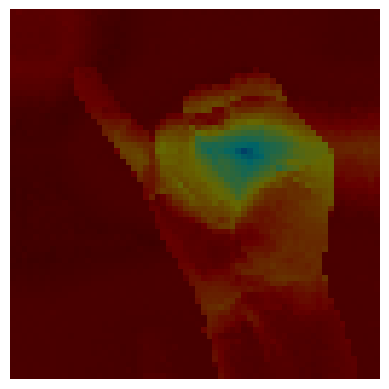

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
9
Energy concentration (top 5%) = 8.4%
Energy concentration (top 10%) = 16.8%
Energy concentration (top 20%) = 33.6%
Entropy of heatmap = 9.256


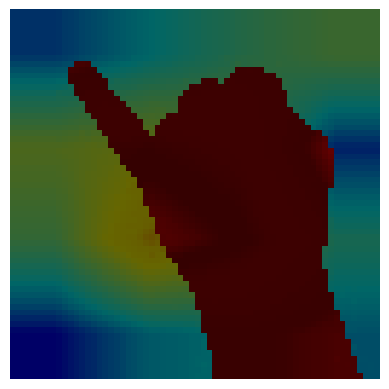

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

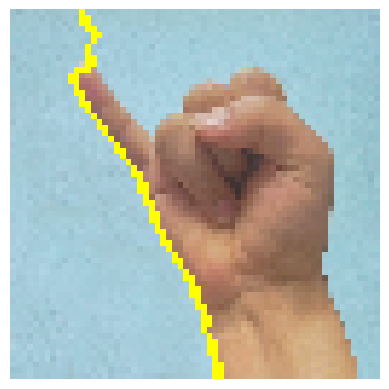

Saved explanation image at: lime_j.jpg
Returned LIME: {0.05: 0.08506277164566697, 0.1: 0.17012554329133395, 0.2: 0.3398361462331768} 8.039482442024578


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

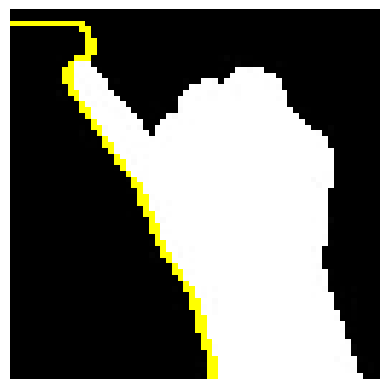

Saved explanation image at: lime_mask_j.jpg
Returned LIME: {0.05: 0.07640700708134027, 0.1: 0.15281401416268053, 0.2: 0.3052553112176472} 7.894690952704497


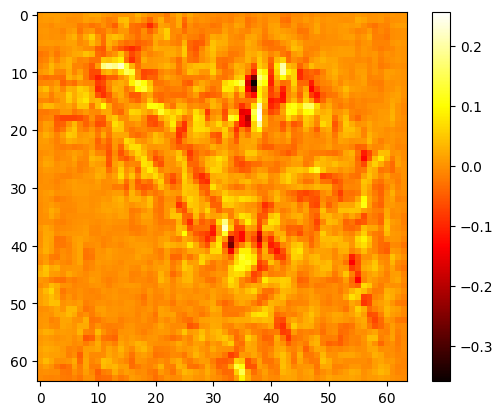

[IG] Energy concentration:
  top-5%  = 6.2%
  top-10% = 11.8%
  top-20% = 22.5%
[IG] Entropy = 8.313


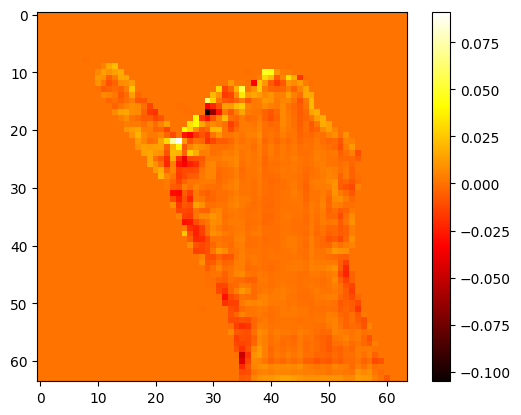

[IG] Energy concentration:
  top-5%  = 5.7%
  top-10% = 10.9%
  top-20% = 21.0%
[IG] Entropy = 8.316


(array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         2.2989596e-05, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         7.0496259e-05, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00]], dtype=float32),
 {0.05: 0.05685751219248892,
  0.1: 0.10884553734193546,
  0.2: 0.20990163677998322},
 8.316131406517826)

In [23]:
image_mask = load_img('mask_j.jpg', target_size=(64, 64))

# Apply Grad-CAM for letter 'j' in RGB
img_grad = gradcam(image_j, model_colour)
img_grad = cv2.resize(img_grad, (500, 500))
cv2.imwrite("image_grad_j.jpg", cv2.cvtColor(img_grad, cv2.COLOR_BGR2RGB))

# Apply Grad-CAM for letter 'j' mask
ima_grad_mask = gradcam(image_mask, model_mask)
ima_grad_mask = cv2.resize(ima_grad_mask, (500, 500))
cv2.imwrite("image_grad_mask_j.jpg", cv2.cvtColor(ima_grad_mask, cv2.COLOR_BGR2RGB))

# LIME explanation
energy_lime, entropy_lime = explain_with_lime(model_colour, image_array_j, 'lime_j.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

image_array = img_to_array(image_mask)/255.0
energy_lime, entropy_lime = explain_with_lime(model_mask, image_array, 'lime_mask_j.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

# Display the heatmap to visualize gradients
integrated_gradients(model_colour, image_input_j, "gradient_j.jpg", target_class_index=9)

image_input = np.expand_dims(image_array, axis=0)
integrated_gradients(model_mask, image_input, "gradient_j_mask.jpg", target_class_index=9)


## Letter m

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
12
Energy concentration (top 5%) = 6.8%
Energy concentration (top 10%) = 13.6%
Energy concentration (top 20%) = 27.3%
Entropy of heatmap = 9.369


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


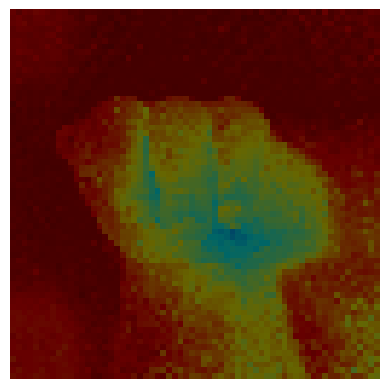

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
12


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_3']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


Energy concentration (top 5%) = 8.5%
Energy concentration (top 10%) = 17.1%
Energy concentration (top 20%) = 34.2%
Entropy of heatmap = 9.252


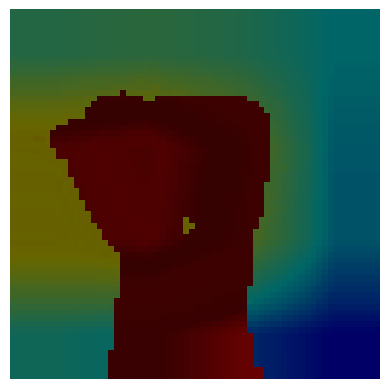

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

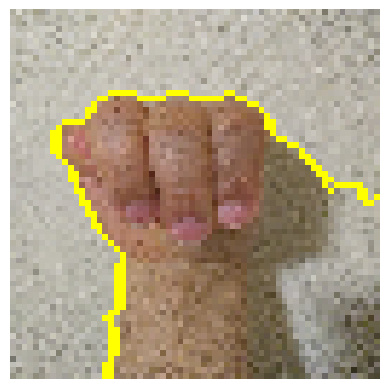

Saved explanation image at: lime_m.jpg
Returned LIME: {0.05: 0.07345930276068027, 0.1: 0.14691860552136055, 0.2: 0.29347887298047387} 8.152048352996056


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

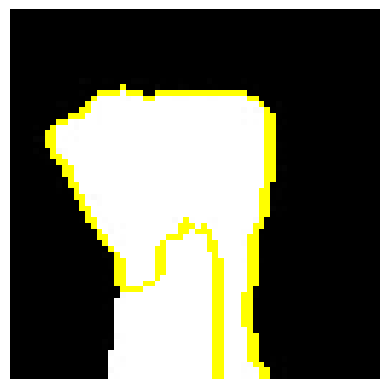

Saved explanation image at: lime_mask_m.jpg
Returned LIME: {0.05: 0.14403678696602237, 0.1: 0.28807357393204475, 0.2: 0.5754445293910845} 7.4435887483743395


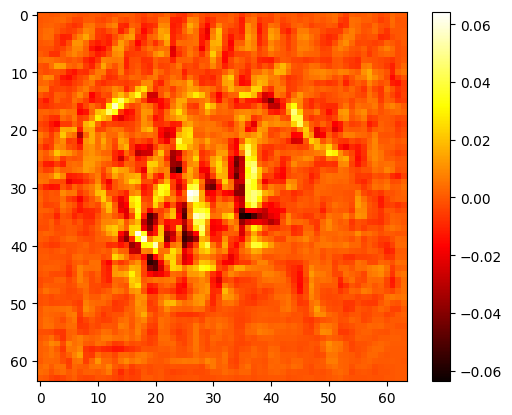

[IG] Energy concentration:
  top-5%  = 7.2%
  top-10% = 13.2%
  top-20% = 24.4%
[IG] Entropy = 8.303


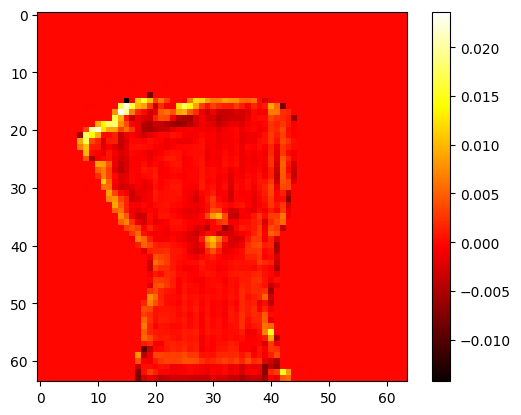

[IG] Energy concentration:
  top-5%  = 7.2%
  top-10% = 12.7%
  top-20% = 22.8%
[IG] Entropy = 8.309


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 {0.05: 0.07211129135270039,
  0.1: 0.1273165298350965,
  0.2: 0.22793537526028795},
 8.309394615663008)

In [24]:
image_mask = load_img('mask_m.jpg', target_size=(64, 64))

# Apply Grad-CAM for letter 'm' in RGB
img_grad = gradcam(image_m, model_colour)
img_grad = cv2.resize(img_grad, (500, 500))
cv2.imwrite("image_grad_m.jpg", cv2.cvtColor(img_grad, cv2.COLOR_BGR2RGB))

# Apply Grad-CAM for letter 'm' mask
ima_grad_mask = gradcam(image_mask, model_mask)
ima_grad_mask = cv2.resize(ima_grad_mask, (500, 500))
cv2.imwrite("image_grad_mask_m.jpg", cv2.cvtColor(ima_grad_mask, cv2.COLOR_BGR2RGB))

# LIME explanation
energy_lime, entropy_lime = explain_with_lime(model_colour, image_array_m, 'lime_m.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

image_array = img_to_array(image_mask)/255.0
energy_lime, entropy_lime = explain_with_lime(model_mask, image_array, 'lime_mask_m.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

# Display the heatmap to visualize gradients
integrated_gradients(model_colour, image_input_m, "gradient_m.jpg", target_class_index=12)

image_input = np.expand_dims(image_array, axis=0)
integrated_gradients(model_mask, image_input, "gradient_m_mask.jpg", target_class_index=12)


## Letter n

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
13
Energy concentration (top 5%) = 6.5%
Energy concentration (top 10%) = 13.1%
Energy concentration (top 20%) = 26.1%
Entropy of heatmap = 9.376


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


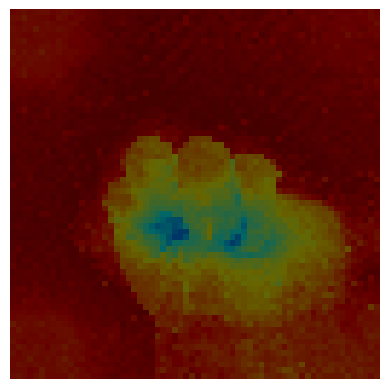

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
12


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_3']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


Energy concentration (top 5%) = 8.7%
Energy concentration (top 10%) = 17.3%
Energy concentration (top 20%) = 34.6%
Entropy of heatmap = 9.245


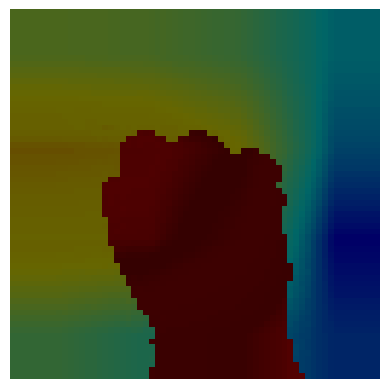

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━

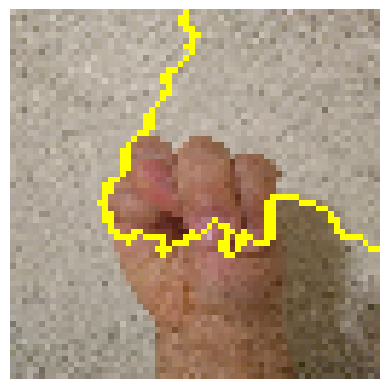

Saved explanation image at: lime_n.jpg
Returned LIME: {0.05: 0.1321521683906419, 0.1: 0.2643043367812838, 0.2: 0.5279640288387109} 7.446032749367269


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

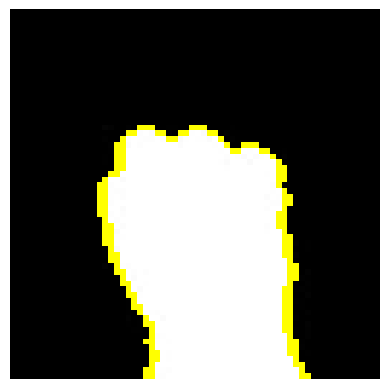

Saved explanation image at: lime_mask_n.jpg
Returned LIME: {0.05: 0.17903930130848003, 0.1: 0.35807860261696006, 0.2: 0.7152838427885129} 7.043160416516086


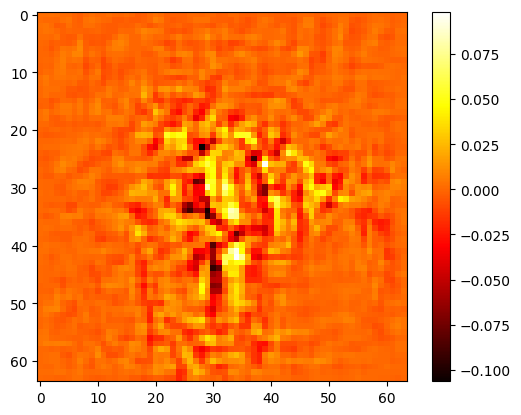

[IG] Energy concentration:
  top-5%  = 6.8%
  top-10% = 12.5%
  top-20% = 23.3%
[IG] Entropy = 8.308


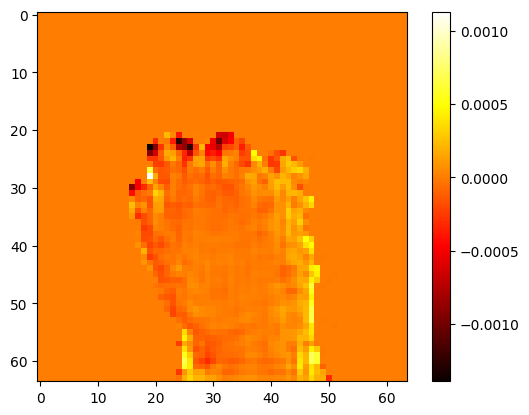

[IG] Energy concentration:
  top-5%  = 5.9%
  top-10% = 11.1%
  top-20% = 21.1%
[IG] Entropy = 8.315


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 {0.05: 0.05898643616848412,
  0.1: 0.1107683968300623,
  0.2: 0.21082018564752691},
 8.314849220088712)

In [27]:
image_mask = load_img('mask_n.jpg', target_size=(64, 64))

# Apply Grad-CAM for letter 'n' in RGB
img_grad = gradcam(image_n, model_colour)
img_grad = cv2.resize(img_grad, (500, 500))
cv2.imwrite("image_grad_n.jpg", cv2.cvtColor(img_grad, cv2.COLOR_BGR2RGB))

# Apply Grad-CAM for letter 'n' mask
ima_grad_mask = gradcam(image_mask, model_mask)
ima_grad_mask = cv2.resize(ima_grad_mask, (500, 500))
cv2.imwrite("image_grad_mask_n.jpg", cv2.cvtColor(ima_grad_mask, cv2.COLOR_BGR2RGB))

# LIME explanation
energy_lime, entropy_lime = explain_with_lime(model_colour, image_array_n, 'lime_n.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

image_array = img_to_array(image_mask)/255.0
energy_lime, entropy_lime = explain_with_lime(model_mask, image_array, 'lime_mask_n.jpg')
print("Returned LIME:", energy_lime, entropy_lime)

# Display the heatmap to visualize gradients
integrated_gradients(model_colour, image_input_n, "gradient_n.jpg", target_class_index=13)

image_input = np.expand_dims(image_array, axis=0)
integrated_gradients(model_mask, image_input, "gradient_n_mask.jpg", target_class_index=13)
